## Machine Learning for Space Applications
# Lab 2: Unsupervised data exploration

1.   Google Satellite Embeddings
2.   CORINE 2018


# Objectives:

1. Construct a large, distributed, balanced GEF/CORINE dataset

    a. Tile the AOI using H3 Hex zoom-level-4 tiles

    b. For each H3z4 cell, tile using H3 Hex zoom-level-6 tiles

    c. Filter and aggregate samples using CORINE dataset

2. UMAP on the entire dataset
3. Apply three different outlier detection method to two different classes
4. Select the best outlier detection method and apply to all classes
5. Visualise and document the results

Authors: 
Martyna Durda, Katarzyna Wcisło

Gemini 3 was used to add comments

In [168]:
import geopandas as gpd
from shapely.geometry import Polygon
import pandas as pd
import h3
import contextily as cx
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import importlib
from dataclasses import dataclass
import random
import ee
import geemap
from sklearn.preprocessing import normalize
import umap
from matplotlib.lines import Line2D


### Set the directory to 'habitat_pl' and authenticate in Gee.

In [123]:
SRC_DIR = os.path.abspath("../src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print("Python path updated. sys.path[0] =", sys.path[0])
print("Folders in SRC_DIR:", os.listdir(SRC_DIR))  # powinno być 'habitat_pl'


ee.Authenticate()
ee.Initialize(project='mlforspace')

import habitat_pl.viz.corine as corine
corine = importlib.reload(corine)
print("Imported successfully!")
corine = importlib.reload(corine)

Python path updated. sys.path[0] = /Users/kasiawcislo/Documents/Studia/ML for space/Machine-Learning-for-space-applications/agh-habitat-pl/src
Folders in SRC_DIR: ['habitat_pl']
Imported successfully!


In [ ]:
def build_preview_map(voivodeship_name: str, year: str = "2021"):
    """
    Create a quick map preview of GSE (Global Satellite Embeddings) + CORINE Land Cover.
    
    Args:
        voivodeship_name: Name of the Polish administrative region (ADM1).
        year: Year for the satellite embedding data.
    """
    # Load administrative boundaries from FAO GAUL level 1 (regions/states)
    geom = (
        ee.FeatureCollection("FAO/GAUL/2015/level1")
        .filter(ee.Filter.eq("ADM1_NAME", voivodeship_name))
        .geometry()
    )

    # Fetch Annual Satellite Embeddings (V1)
    # These are low-dimensional representations of multispectral satellite data
    start, end = f"{year}-01-01", f"{int(year)+1}-01-01"
    emb_img = (
        ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")
        .filterDate(start, end)
        .filterBounds(geom)
        .mosaic() # Combine multiple scenes into a single image
        .clip(geom) # Clip to the administrative boundary
    )

    # Process CORINE Land Cover 2018 (100m resolution)
    # We remap original class codes to sequential indices for easier visualization/processing
    clc_raw = ee.Image("COPERNICUS/CORINE/V20/100m/2018").select("landcover").clip(geom)
    clc_i = clc_raw.remap(
        corine.codes, 
        list(range(1, len(corine.codes) + 1))
    ).rename("landcover_idx")

    # Initialize interactive geemap
    mm = geemap.Map()
    mm.centerObject(geom, 8)
    
    # Add layers to map
    # A01, A16, A09 are specific bands from the Embedding collection visualized as RGB
    mm.addLayer(emb_img, {"min": -0.3, "max": 0.3, "bands": ["A01", "A16", "A09"]}, f"Embeddings {year}")
    mm.addLayer(clc_i, corine.vis, "CORINE 2018")
    
    # Attach a legend for Corine classes
    _ = mm.add_legend(title="CORINE Land Cover 2018", legend_dict=corine.legend_dict)
    
    return mm, geom, emb_img, clc_i

# Initial run for the Podkarpackie region
m, region, emb, clc_idx = build_preview_map("Podkarpackie", year="2021")
m

# Configuration parameters for dimensionality reduction and sampling
@dataclass(frozen=True)
class Params:
    YEAR: int = 2021
    MAX_PER_CLASS: int = 250        # Limit samples per Corine class to handle memory constraints
    SEED: int = 42                   # Seed for reproducibility
    TSNE_PERPLEXITY: int = 30        # Controls local vs global structure in t-SNE
    UMAP_N_NEIGHBORS: int = 25       # Size of local neighborhood for UMAP
    UMAP_MIN_DIST: float = 0.1       # Effective minimum distance between points in UMAP

P = Params()

# Unpacking params for global access
YEAR = P.YEAR
MAX_PER_CLASS = P.MAX_PER_CLASS
SEED = P.SEED
TSNE_PERPLEXITY = P.TSNE_PERPLEXITY
UMAP_N_NEIGHBORS = P.UMAP_N_NEIGHBORS
UMAP_MIN_DIST = P.UMAP_MIN_DIST

# Set random seeds for consistent results across Python, NumPy, and random modules
random.seed(SEED)
np.random.seed(SEED)

# Generate final objects for the specified study year
m, region, emb, clc_idx = build_preview_map("Podkarpackie", year=str(YEAR))
m

Map(center=[49.95233161411762, 22.169400120254295], controls=(WidgetControl(options=['position', 'transparent_…

In [135]:
def read_drawn_aoi(map_obj):
    """
    Extracts the user-drawn Area of Interest (AOI) from a geemap instance.
    
    This function checks for regions of interest created via the interactive 
    drawing tools on the map and centers the view on that geometry.
    """
    # Attempt to retrieve the last drawn object from geemap internal attributes
    # 'user_roi' and 'draw_last_feature' are standard geemap containers for drawn shapes
    feat = getattr(map_obj, "user_roi", None) or getattr(map_obj, "draw_last_feature", None)
    
    if feat is None:
        raise ValueError("No AOI detected. Please draw a polygon on the map first.")
    
    # Earth Engine Object Handling:
    # Check if the drawn object is a Feature, FeatureCollection, or raw Geometry
    if isinstance(feat, ee.Feature):
        geom = feat.geometry()
    elif isinstance(feat, ee.FeatureCollection):
        # In case of multiple shapes, extract geometry from the first element
        geom = feat.first().geometry()
    else:
        # If the object is already an ee.Geometry instance, use it directly
        geom = feat

    # Zoom the map view to the detected geometry at a specific zoom level
    map_obj.centerObject(geom, 12)
    return geom

# Retrieve the Area of Interest (AOI) from the map instance 'm'
AOI_ee = read_drawn_aoi(m)

# Log the AOI structure
# .getInfo() triggers a server-to-client request to return the GeoJSON representation
print("AOI GeoJSON Structure:", AOI_ee.getInfo())

AOI GeoJSON Structure: {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[21.324463, 49.624946], [21.324463, 50.830228], [23.763428, 50.830228], [23.763428, 49.624946], [21.324463, 49.624946]]]}


Number of H3 z4 cells: 14
                h3        lat        lon corine
0  861e2b807ffffff  50.029584  22.437918   None
1  861e2b80fffffff  50.010079  22.523975   None
2  861e2b817ffffff  49.994778  22.366360   None
3  861e2b81fffffff  49.975316  22.452394   None
4  861e2b827ffffff  50.083808  22.423421   None
Total Samples (z6): 686
Final Count of H3 z6 cells: 686


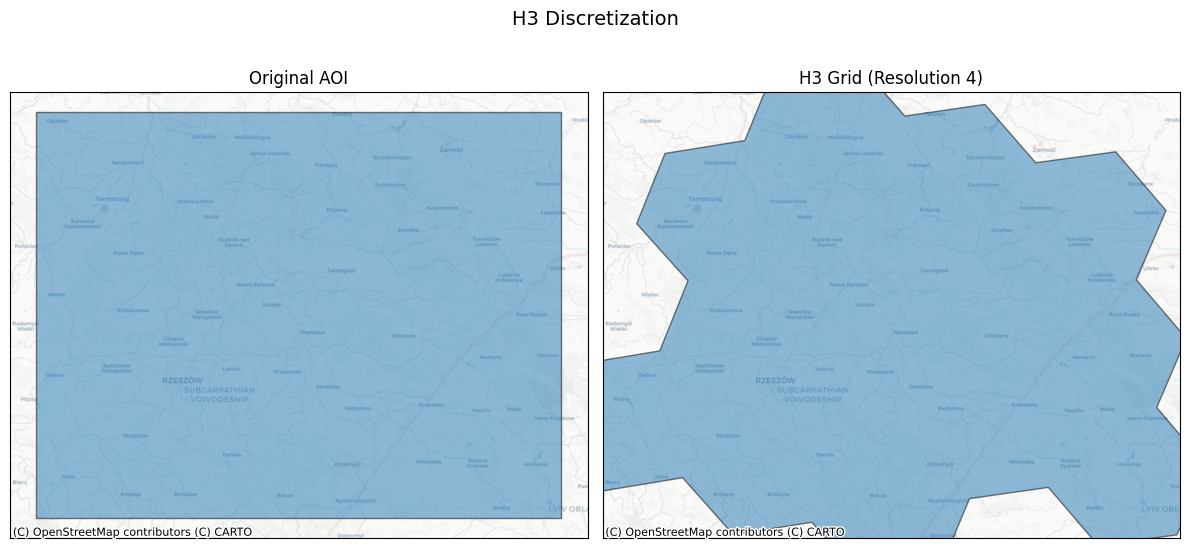

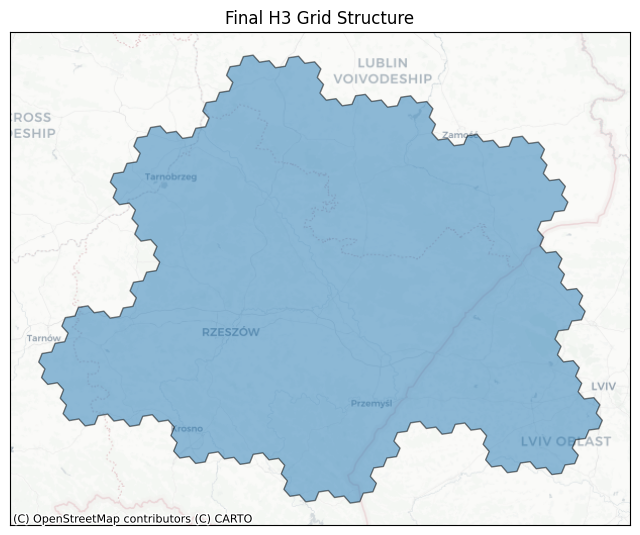

In [ ]:
def plot_df(df, column=None, ax=None, title=None):
    """
    Plot a GeoPandas DataFrame with a basemap.
    
    Args:
        df: GeoDataFrame to plot.
        column: Attribute column for coloring.
        ax: Matplotlib axis object.
        title: Title string for the plot.
    """
    df = df.copy()
    # Convert to Web Mercator for compatibility with contextily basemaps
    df = df.to_crs(epsg=3857)

    if ax is None:
        _, ax = plt.subplots(figsize=(8,8))
    
    # Clean up the axes for a better map aesthetic
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    df.plot(
        ax=ax,
        alpha=0.5, 
        edgecolor='k',
        column=column, 
        categorical=True,
        legend=True, 
        legend_kwds={'loc': 'upper left'},
    )
    
    # Add a clean grayscale basemap
    cx.add_basemap(ax, crs=df.crs, source=cx.providers.CartoDB.Positron)
    
    if title:
        ax.set_title(title, fontsize=12)


def plot_shape(shape, ax=None, title="Geometry Outline"):
    """Convert a Shapely shape to a GeoDataFrame and plot it."""
    df = gpd.GeoDataFrame({'geometry': [shape]}, crs='EPSG:4326')
    plot_df(df, ax=ax, title=title)


def plot_cells(cells, ax=None, title="H3 Grid"):
    """Convert H3 indices back to a shape and plot."""
    shape = h3.cells_to_h3shape(cells)
    plot_shape(shape, ax=ax, title=title)


def plot_shape_and_cells(shape, res=9, main_title="H3 Discretization"):
    """Compare the original vector shape with the resulting H3 hexagonal grid."""
    fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)
    
    # Plot 1: The original Area of Interest
    plot_shape(shape, ax=axs[0], title="Original AOI")
    
    # Plot 2: The H3 hex-grid representation
    cells = h3.h3shape_to_cells(shape, res)
    plot_cells(cells, ax=axs[1], title=f"H3 Grid (Resolution {res})")
    
    fig.suptitle(main_title, fontsize=14)
    fig.tight_layout()


def polygon_to_h3(geometry, resolution):
    """
    Convert a Shapely Polygon into a list of H3 indices at a specific resolution.
    """
    if geometry.is_empty:
        return []
    
    # H3-py expects (lat, lon) for some inputs, but geo_to_h3shape 
    # uses GeoJSON standard (lon, lat).
    coords = [[(x, y) for x, y in geometry.exterior.coords]]
    geo_json = {"type": "Polygon", "coordinates": coords}
    
    # Convert GeoJSON dict to H3 shape and fill with cells
    h3_shape = h3.geo_to_h3shape(geo_json)
    cells = h3.h3shape_to_cells(h3_shape, resolution)
    
    # Visualize the conversion process
    plot_shape_and_cells(h3_shape, res=resolution)
    
    return list(cells)

# --- Execution Logic ---

# Convert the Earth Engine AOI into a Shapely Polygon
coords = AOI_ee.getInfo()['coordinates'][0]  # Extracts [lon, lat] list
polygon_shape = Polygon(coords)

# Phase 1: Generate coarse H3 cells (Resolution 4) for high-level indexing
h3_z4_cells = polygon_to_h3(polygon_shape, 4)
print(f"Number of H3 z4 cells: {len(h3_z4_cells)}")

# Phase 2: Upsample/Refine z4 cells to z6 cells for higher granularity
h3_z6_cells = []
for cell in h3_z4_cells:
    children = h3.cell_to_children(cell, 6)
    h3_z6_cells.extend(children)

# Prepare the data for DataFrame integration
records = []
for cell in h3_z6_cells:
    lat, lon = h3.cell_to_latlng(cell)
    records.append({
        "h3": cell,
        "lat": lat,
        "lon": lon,
        "corine": None  # Placeholder for subsequent CORINE data extraction
    })

df = pd.DataFrame(records)
print(df.head())
print("Total Samples (z6):", len(df))

# Final visualization of the refined z6 grid overlaid on the z4 footprint
plot_cells(h3_z6_cells, title="Final H3 Grid Structure")

print(f"Final Count of H3 z6 cells: {len(h3_z6_cells)}")

In [144]:
def corine_2018_idx(geometry):
    raw = ee.Image("COPERNICUS/CORINE/V20/100m/2018").select("landcover").rename("corine")
    raw = raw.reproject(crs="EPSG:3035", scale=100).clip(geometry)
    idx = raw.remap(corine.codes, list(range(1, len(corine.codes) + 1))).rename("landcover_idx")
    return raw, idx

# CORINE 2018
clc_raw, clc_idx = corine_2018_idx(AOI_ee)


In [ ]:
def h3_to_ee_feature(h3_index):
    """
    Converts an H3 index into a Google Earth Engine Feature.
    Handles the coordinate flip from (lat, lon) to (lon, lat).
    """
    # Get the vertices of the hexagon
    boundary_latlon = h3.cell_to_boundary(h3_index)
    
    # 🔥 COORDINATE CONVERSION: h3 uses (lat, lon), but GEE expects (lon, lat)
    boundary_lonlat = [[lon, lat] for lat, lon in boundary_latlon]
    
    geom = ee.Geometry.Polygon([boundary_lonlat])
    return ee.Feature(geom, {"h3": h3_index})

# Create a FeatureCollection from the list of H3 resolution 6 cells
hex_fc = ee.FeatureCollection(
    [h3_to_ee_feature(h) for h in h3_z6_cells]
)

# Zonal Statistics: Reduce the CORINE image regions by the hexagon collection.
# We use frequencyHistogram to count occurrences of each land-cover class per hex.
hex_corine = clc_idx.reduceRegions(
    collection=hex_fc,
    reducer=ee.Reducer.frequencyHistogram(),
    scale=100, # Scale matches CORINE 100m resolution
)


def histogram_to_fraction(f):
    """
    GEE Map Function: Converts raw pixel counts into land-cover fractions (0.0 to 1.0).
    Also extracts the centroid coordinates for each hexagon.
    """
    hist = ee.Dictionary(f.get("histogram"))

    # Calculate total pixels in the hexagon
    total = ee.Number(
        hist.values().reduce(ee.Reducer.sum())
    )

    # Convert counts to proportions (fractions)
    frac = hist.map(
        lambda k, v: ee.Number(v).divide(total)
    )

    # Calculate the geographic center of the hexagon
    centroid = f.geometry().centroid()
    lon = centroid.coordinates().get(0)
    lat = centroid.coordinates().get(1)

    return (
        f
        .set("corine_frac", frac)
        .set("lon", lon)
        .set("lat", lat)
    )

# Apply the fraction calculation across the entire collection
hex_corine = hex_corine.map(histogram_to_fraction)

# Transfer data from GEE servers to local Python environment
# Note: getInfo() can be slow for very large collections
features = hex_corine.getInfo()["features"]

# Parse the GEE response into a list of dictionaries for Pandas
records = []
for f in features:
    props = f["properties"]
    records.append({
        "h3": props["h3"],
        "lat": props.get("lat"),
        "lon": props.get("lon"),
        "corine_hist": props.get("histogram"), # Raw pixel counts
        "corine_frac": props.get("corine_frac")  # Percentage composition
    })

# Initialize final DataFrame for analysis
df = pd.DataFrame(records)
print("Data Extraction Complete. Preview:")
print(df.head())

Data Extraction Complete. Preview:
                h3        lat        lon  \
0  861e2b807ffffff  50.029578  22.437918   
1  861e2b80fffffff  50.010073  22.523975   
2  861e2b817ffffff  49.994772  22.366360   
3  861e2b81fffffff  49.975310  22.452394   
4  861e2b827ffffff  50.083802  22.423421   

                                         corine_hist  \
0  {'12': 2796.8784313725478, '18': 222.545098039...   
1  {'12': 2303.2745098039213, '18': 388.094117647...   
2  {'12': 2793.0196078431372, '16': 163.545098039...   
3  {'12': 2565.1529411764695, '16': 128.125490196...   
4  {'12': 2334.6470588235293, '18': 396.607843137...   

                                         corine_frac  
0  {'12': 0.7999291149235517, '18': 0.06364963929...  
1  {'12': 0.6584635495494283, '18': 0.11094892474...  
2  {'12': 0.798265877165552, '16': 0.046742411251...  
3  {'12': 0.7328269418209927, '16': 0.03660359179...  
4  {'12': 0.6684815928531807, '18': 0.11356108055...  


In [150]:
def get_dominant_color(frac_dict):
    """
    Determines a representative color for an H3 cell based on its dominant CORINE class.
    
    The function identifies which land-cover class has the highest percentage 
    within the hexagon and maps it to a standard color category.
    """
    if not frac_dict:
        # Fallback for hexagons with no underlying land-cover data
        return "gray"
    
    # Identify the class code (key) with the maximum fraction value
    dominant_class = max(frac_dict, key=lambda k: frac_dict[k])
    
    # Categorical Color Logic based on CORINE Level 1 classifications:
    # 1xx: Artificial surfaces (Urban, Industrial) -> Dark Red
    # 2xx: Agricultural areas -> Orange
    # 3xx: Forests and semi-natural areas -> Green
    # 4xx: Wetlands -> Cyan
    # 5xx: Water bodies -> Blue
    c = int(dominant_class)
    
    if c < 200: 
        return "darkred"   # Artificial surfaces
    if c < 300: 
        return "orange"    # Agricultural
    if c < 400: 
        return "green"     # Forest/Natural
    if c < 500: 
        return "cyan"      # Wetlands
    
    return "blue"          # Water bodies

# Apply the color logic to the DataFrame to create a styling column
df['dominant_color'] = df['corine_frac'].apply(get_dominant_color)

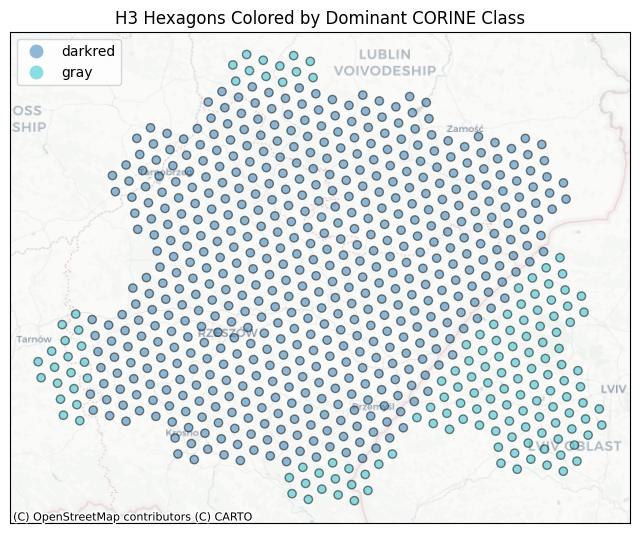

In [ ]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
)
plot_df(gdf, column='dominant_color', title="H3 Hexagons Colored by Dominant CORINE Class")

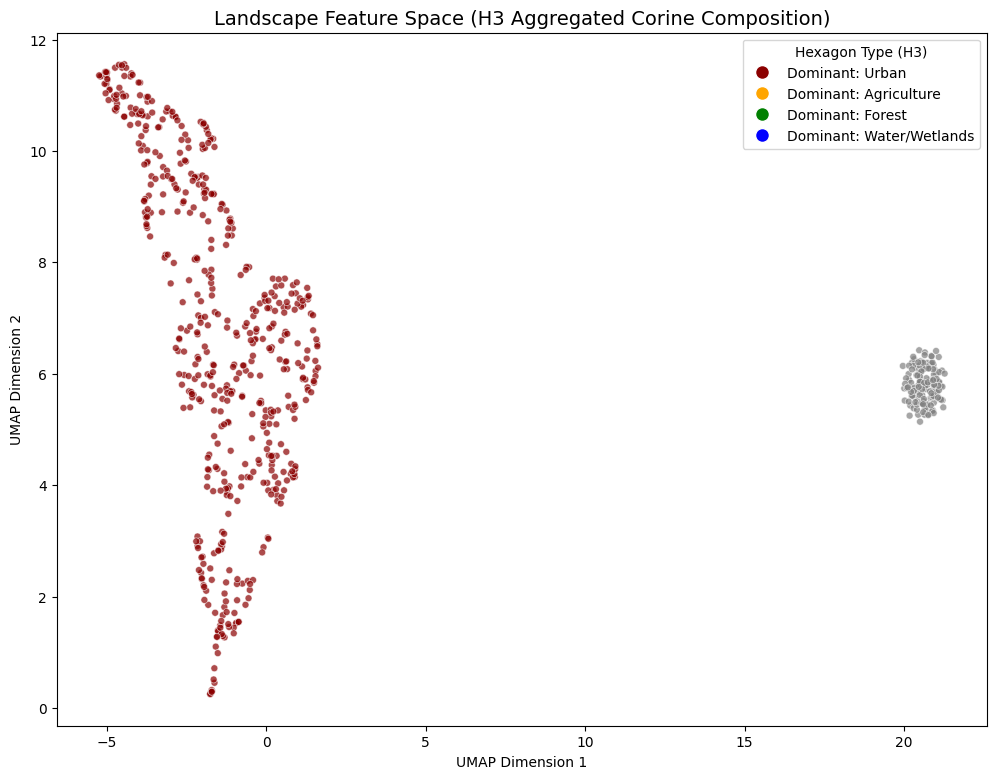

In [ ]:
# 1. Feature Matrix Construction
# Collect all unique CORINE classes present in the dataset to define the matrix dimensions
all_classes = sorted({
    int(k) for d in df["corine_frac"] if isinstance(d, dict) for k in d.keys()
})

# Initialize a zero matrix where rows = hexagons and columns = CORINE classes
X = np.zeros((len(df), len(all_classes)))
for i, d in enumerate(df["corine_frac"]):
    if not isinstance(d, dict): continue
    for j, cls in enumerate(all_classes):
        # Fill matrix with fractional values (0.0 - 1.0)
        X[i, j] = d.get(str(cls), 0)

# 2. Normalization and UMAP Dimensionality Reduction
# L1 normalization ensures each row sums to 1, focusing on the relative composition
X_norm = normalize(X, norm="l1")

# UMAP (Uniform Manifold Approximation and Projection) is used to capture 
# the non-linear relationships between different landscape patterns.
reducer = umap.UMAP(
    n_neighbors=15,    # Balance between local and global structure
    min_dist=0.1,      # How tightly UMAP packs points together
    random_state=42    # Seed for reproducibility
)
embedding = reducer.fit_transform(X_norm)

# Store the 2D coordinates back into the DataFrame
df["emb_x"] = embedding[:, 0]
df["emb_y"] = embedding[:, 1]

# 3. Scatter Plot Visualization
plt.figure(figsize=(12, 9), facecolor='white')
plt.scatter(
    df["emb_x"], 
    df["emb_y"], 
    c=df['dominant_color'], # Colored by the classification logic defined earlier
    s=25, 
    alpha=0.7, 
    edgecolors='white', 
    linewidth=0.5
)



# Create a custom legend to map colors to their general landscape categories
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Dominant: Urban', markerfacecolor='darkred', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Dominant: Agriculture', markerfacecolor='orange', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Dominant: Forest', markerfacecolor='green', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Dominant: Water/Wetlands', markerfacecolor='blue', markersize=10)
]

plt.legend(handles=legend_elements, title="Hexagon Type (H3)")
plt.title("Landscape Feature Space (H3 Aggregated Corine Composition)", fontsize=14)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.show()

In [ ]:


# 1. Color Classification Logic (Server-side GEE Logic)
def add_style_properties(f):
    """
    Applies conditional styling logic directly on the GEE server.
    Uses ee.Algorithms.If to determine colors based on the CORINE Level 1 code.
    """
    c = ee.Number(f.get("corine"))
    
    # Nested GEE conditional logic (required as standard Python 'if' doesn't run on GEE servers)
    color = ee.Algorithms.If(
        c.lt(0), "gray",                             # No Data / NaN
        ee.Algorithms.If(
            c.lt(200), "darkred",                    # Urban / Artificial surfaces
            ee.Algorithms.If(
                c.lt(300), "orange",                 # Agricultural areas
                ee.Algorithms.If(
                    c.lt(400), "green",              # Forests and semi-natural
                    ee.Algorithms.If(
                        c.lt(500), "cyan",           # Wetlands
                        "blue"                       # Water bodies
                    )
                )
            )
        )
    )
    
    # Set a 'style' dictionary compatible with ee.FeatureCollection.style() or geemap
    return f.set({
        "style": {
            "color": color,
            "pointSize": 5
        }
    })


# --- CORINE Raster Visualization Palette ---
# Standardized palette for the original CORINE 100m raster dataset
corine_vis = {
    "min": 100,
    "max": 523,
    "palette": [
        "e6004d","ff0000","cc4df2","cc0000","e6cccc",  # Artificial/Urban
        "e6cce6","a600cc","a64d00","ff4d4d","ffa6a6",
        "ffe6ff","ffffa8","ffff00","e6e600","e6ff00",
        "e6ffcc","80ff00","00a600","4dff00","ccf24d",
        "a6ff80","a6e64d","a6ffcc","4dffa6","00ccf2",
        "80f2e6","00ffa6","a6ffe6","e6f2ff","ccccff",
        "e6e6ff","a6a6ff","4d4dff","cccccc","a6a6a6"
    ]
}

import geemap

# 2. Prepare Features for GEE (passing the numerical class for styling)
ee_features = []
for _, row in df.iterrows():
    point = ee.Geometry.Point([row.lon, row.lat])
    
    # We extract the dominant class ID from the fraction dictionary
    # so the GEE server-side 'If' logic can process the numbers.
    fracs = row.corine_frac
    dom_class = int(max(fracs, key=lambda k: fracs[k])) if fracs else -1
    
    feature = ee.Feature(point, {"corine": dom_class})
    ee_features.append(feature)

# 3. Create and Style the Collection
ee_fc = ee.FeatureCollection(ee_features)
# add_style_properties is the function you defined in the previous step
styled_points = ee_fc.map(add_style_properties)

# 3. Initialize Map
m_final = geemap.Map()
m_final.centerObject(AOI_ee, 11)

# Layer 1: The Original CORINE Raster (Reference)
m_final.addLayer(clc_idx, corine.vis, "CORINE 2018")

# Layer 2: H3 Hexagon Boundaries
# We style the hex_fc to have transparent fill and black outlines
hex_outlines = hex_fc.style(color="black", fillColor="00000000", width=1)
m_final.addLayer(hex_outlines, {}, "H3 Hex Grid (z6)")

# Layer 3: Styled Classification Points
# This uses the 'style' property we set in add_style_properties
m_final.addLayer(styled_points.style(styleProperty="style"), {}, "Dominant Land Cover Points")

# Add a Legend for clarity
legend_dict = {
    'Urban/Artificial': 'darkred',
    'Agriculture': 'orange',
    'Forest/Natural': 'green',
    'Wetlands': 'cyan',
    'Water': 'blue',
    'No Data': 'gray'
}
m_final.add_legend(title="Dominant H3 Classification", legend_dict=legend_dict)

m_final

Map(center=[50.227175625070686, 22.54394549999992], controls=(WidgetControl(options=['position', 'transparent_…

In [ ]:


# Filter data for two classes: Urban (1xx) and Forest (3xx)
# We define them based on the dominant class calculated in the previous step
df_urban = df[df['dominant_color'] == 'darkred'].copy()
df_forest = df[df['dominant_color'] == 'green'].copy()

# Features for outlier detection (the X matrix we built earlier)
# Using only the columns corresponding to the classes present in these subsets

In [164]:
# 1. Expand the 'corine_frac' dictionary into individual columns
# json_normalize turns {'111': 0.5, '211': 0.5} into separate columns for each class.
# We fill NaN with 0 because a missing class in a hexagon means it has 0% coverage.
fractions_df = pd.json_normalize(df['corine_frac']).fillna(0)

# 2. Ensure all column names are strings
# This maintains consistency, especially when dealing with numeric CORINE codes as headers.
fractions_df.columns = [str(col) for col in fractions_df.columns]

# 3. Concatenate the new fraction columns with the main DataFrame
# We reset the index to ensure the rows align perfectly during the side-by-side join.
df = pd.concat([df.reset_index(drop=True), fractions_df], axis=1)

# 4. Filter and verify the feature columns
# Create a list of column names that exist in the DataFrame and correspond 
# to our known CORINE classes. These will be used as input for our models.
feature_cols = [str(c) for c in all_classes if str(c) in df.columns]

# Display the first few rows of the flattened feature matrix
print(f"Total features (CORINE classes) identified: {len(feature_cols)}")
print(df[feature_cols].head())

Total features (CORINE classes) identified: 26
     1    1         2         2    3    3         4         4    6    6  ...  \
0  0.0  0.0  0.123922  0.123922  0.0  0.0  0.000000  0.000000  0.0  0.0  ...   
1  0.0  0.0  0.088557  0.088557  0.0  0.0  0.000000  0.000000  0.0  0.0  ...   
2  0.0  0.0  0.068323  0.068323  0.0  0.0  0.000000  0.000000  0.0  0.0  ...   
3  0.0  0.0  0.141363  0.141363  0.0  0.0  0.000000  0.000000  0.0  0.0  ...   
4  0.0  0.0  0.048764  0.048764  0.0  0.0  0.016734  0.016734  0.0  0.0  ...   

    32   32   35   35   36   36   40   40        41        41  
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.000000  0.000000  
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.000000  0.000000  
2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.000000  0.000000  
3  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.000000  0.000000  
4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.010598  0.010598  

[5 rows x 52 columns]


In [ ]:
from scipy import stats
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest

def apply_outlier_methods(sub_df, features):
    """
    Apply multiple anomaly detection techniques to a subset of H3 cells.
    
    This function compares each hexagon against the 'norm' of its group 
    (e.g., comparing one urban cell against all other urban cells).
    """
    if sub_df.empty:
        return sub_df
    
    # Extract the feature matrix for the specific subset
    X_sub = sub_df[features].values
    
    # 1. Z-Score Analysis (Univariate Outlier Detection)
    # Identifies cells where at least one land-cover percentage is 
    # more than 3 standard deviations from the mean.
    z_scores = np.abs(stats.zscore(X_sub, axis=0))
    # Handle features with zero variance (e.g., if no cells have a specific class)
    z_scores = np.nan_to_num(z_scores)
    # Mark as outlier if ANY feature exceeds the threshold
    sub_df['outlier_zscore'] = (z_scores > 3).any(axis=1)
    
    # 2. Local Outlier Factor (LOF) (Density-Based Detection)
    # Measures the local density deviation of a cell compared to its neighbors.
    # It detects cells that are 'isolated' in the feature space.
    lof = LocalOutlierFactor(n_neighbors=min(20, len(sub_df)-1), contamination=0.05)
    sub_df['outlier_lof'] = lof.fit_predict(X_sub) == -1
    
    # 3. Isolation Forest (Tree-Based Anomaly Detection)
    # Isolates observations by randomly selecting a feature and a split value.
    # Anomalies are easier to isolate and thus have shorter paths in the trees.
    iso = IsolationForest(contamination=0.05, random_state=42)
    sub_df['outlier_iso'] = iso.fit_predict(X_sub) == -1
    
    return sub_df

# --- Execution for specific Land Cover strata ---

# Separate the data into strata to find outliers relative to their own type
# (e.g., an 'outlier' forest is more interesting than comparing a forest to a city)
df_urban = df[df['dominant_color'] == 'darkred'].copy()
df_forest = df[df['dominant_color'] == 'green'].copy()

# Apply the outlier detection pipeline
df_urban = apply_outlier_methods(df_urban, feature_cols)
df_forest = apply_outlier_methods(df_forest, feature_cols)

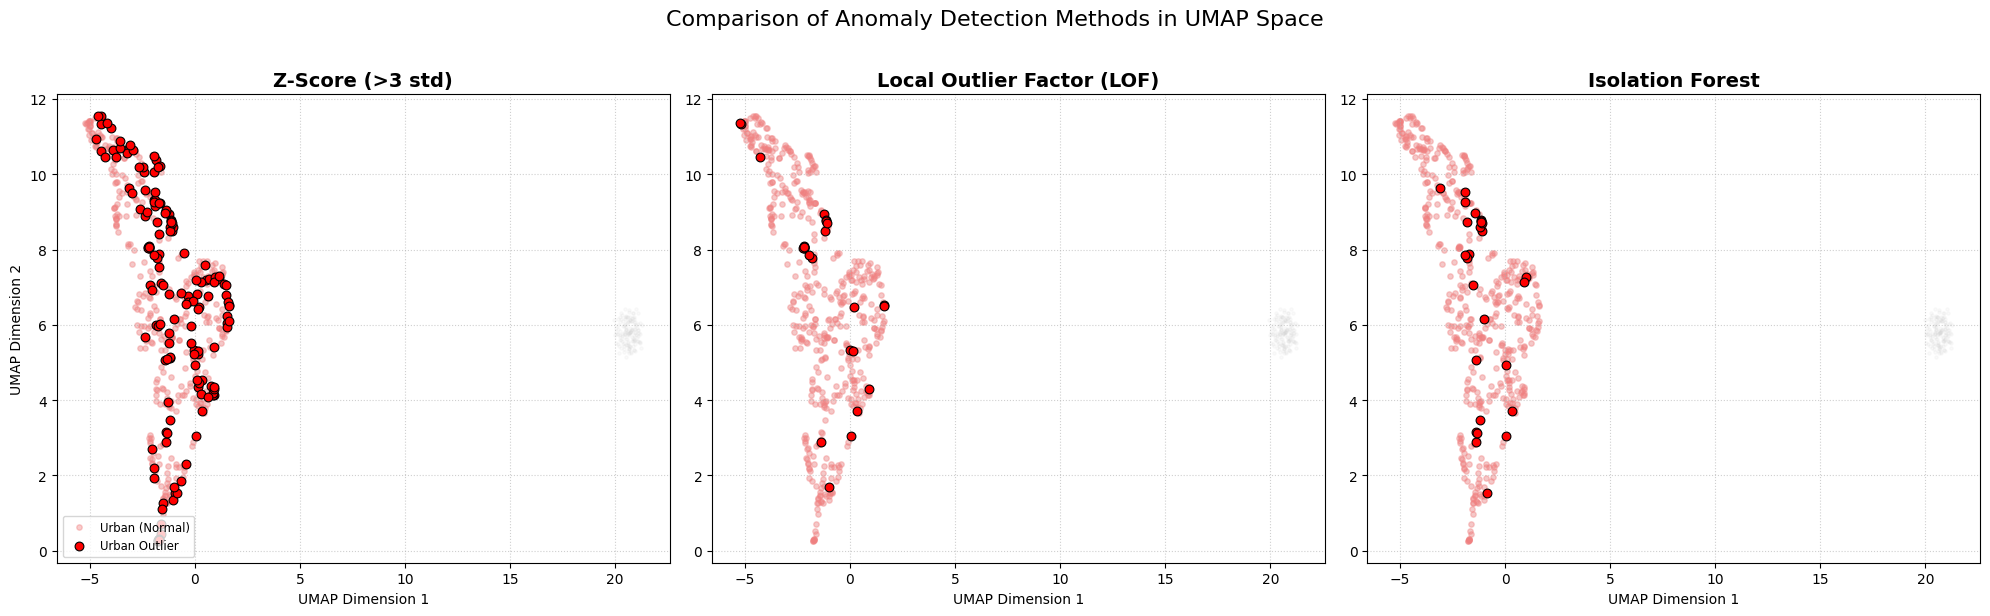

In [165]:
# 1. Define detection methods and descriptive titles
# We are comparing three distinct mathematical approaches to identifying "unusual" hexagons.
methods = ['outlier_zscore', 'outlier_lof', 'outlier_iso']
titles = ['Z-Score (>3 std)', 'Local Outlier Factor (LOF)', 'Isolation Forest']

# Create a side-by-side comparison to evaluate model agreement
fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor='white')

for i, method in enumerate(methods):
    ax = axes[i]
    
    # Background Context: Plot all data points as faint grey dots.
    # This helps visualize the "manifold" or shape of the entire dataset.
    ax.scatter(df["emb_x"], df["emb_y"], c='lightgrey', alpha=0.1, s=5, zorder=1)
    
    # --- URBAN STRATA ANALYSIS ---
    if method in df_urban.columns:
        # Normal Urban points (Typical city/industrial landscapes)
        norm_urb = df_urban[~df_urban[method]]
        ax.scatter(norm_urb["emb_x"], norm_urb["emb_y"], c='lightcoral', alpha=0.4, s=15, label='Urban (Normal)')
        
        # Urban Outliers (Atypical city layouts or unusual land-cover mixes)
        out_urb = df_urban[df_urban[method]]
        if not out_urb.empty:
            ax.scatter(out_urb["emb_x"], out_urb["emb_y"], c='red', s=40, 
                       edgecolors='black', linewidth=0.8, zorder=5, label='Urban Outlier')
    
    # --- FOREST STRATA ANALYSIS ---
    if method in df_forest.columns:
        # Normal Forest points (Typical natural/semi-natural areas)
        norm_for = df_forest[~df_forest[method]]
        ax.scatter(norm_for["emb_x"], norm_for["emb_y"], c='lightgreen', alpha=0.4, s=15, label='Forest (Normal)')
        
        # Forest Outliers (e.g., forests with unusual road density or water bodies)
        out_for = df_forest[df_forest[method]]
        if not out_for.empty:
            ax.scatter(out_for["emb_x"], out_for["emb_y"], c='darkgreen', s=40, 
                       edgecolors='black', linewidth=0.8, zorder=5, label='Forest Outlier')

    # Formatting and Styling
    ax.set_title(titles[i], fontsize=14, fontweight='bold')
    ax.set_xlabel("UMAP Dimension 1")
    
    # Only show Y-axis label and Legend on the first plot to reduce clutter
    if i == 0:
        ax.set_ylabel("UMAP Dimension 2")
        ax.legend(loc='lower left', fontsize='small', frameon=True)
        
    ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle("Comparison of Anomaly Detection Methods in UMAP Space", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [166]:
from sklearn.ensemble import IsolationForest

def detect_outliers_all_classes(df, features, contamination=0.05):
    """
    Perform global anomaly detection across all H3 cells using Isolation Forest.
    
    Args:
        df: The flattened DataFrame containing land-cover fractions.
        features: List of string column names representing CORINE classes.
        contamination: The expected proportion of outliers in the dataset.
    """
    # Create a copy to ensure the original DataFrame remains unchanged
    df_result = df.copy()
    
    # Initialize the Isolation Forest model
    # n_estimators=100: Number of trees in the forest.
    # contamination=0.05: Flags approximately 5% of the data as anomalies.
    iso_forest = IsolationForest(
        n_estimators=100, 
        contamination=contamination, 
        random_state=42
    )
    
    # Prepare the feature matrix (fraction values for all classes)
    X = df_result[features].values
    
    # Prediction: Returns 1 for normal observations and -1 for outliers
    preds = iso_forest.fit_predict(X)
    
    # Binary flag: True if the cell is an anomaly
    df_result['is_outlier'] = (preds == -1)
    
    # Outlier Score: The anomaly score of the input samples.
    # Lower (more negative) values indicate a higher degree of abnormality.
    # A score of 0 typically acts as the decision threshold.
    df_result['outlier_score'] = iso_forest.decision_function(X)
    
    return df_result

# --- Execution ---

# Run detection using the previously prepared 'feature_cols'
df_final = detect_outliers_all_classes(df, feature_cols)



print(f"Global analysis complete.")
print(f"Total outliers detected across all classes: {df_final['is_outlier'].sum()}")

# Quick look at the most 'extreme' outliers (lowest scores)
print("\nTop 5 most anomalous H3 cells:")
print(df_final.nsmallest(5, 'outlier_score')[['h3', 'outlier_score', 'dominant_color']])

Global analysis complete.
Total outliers detected across all classes: 35

Top 5 most anomalous H3 cells:
                  h3  outlier_score dominant_color
202  861e28037ffffff      -0.167183        darkred
237  861e28177ffffff      -0.093912        darkred
384  861e2ab77ffffff      -0.086784        darkred
217  861e280c7ffffff      -0.086431        darkred
221  861e280e7ffffff      -0.082904        darkred


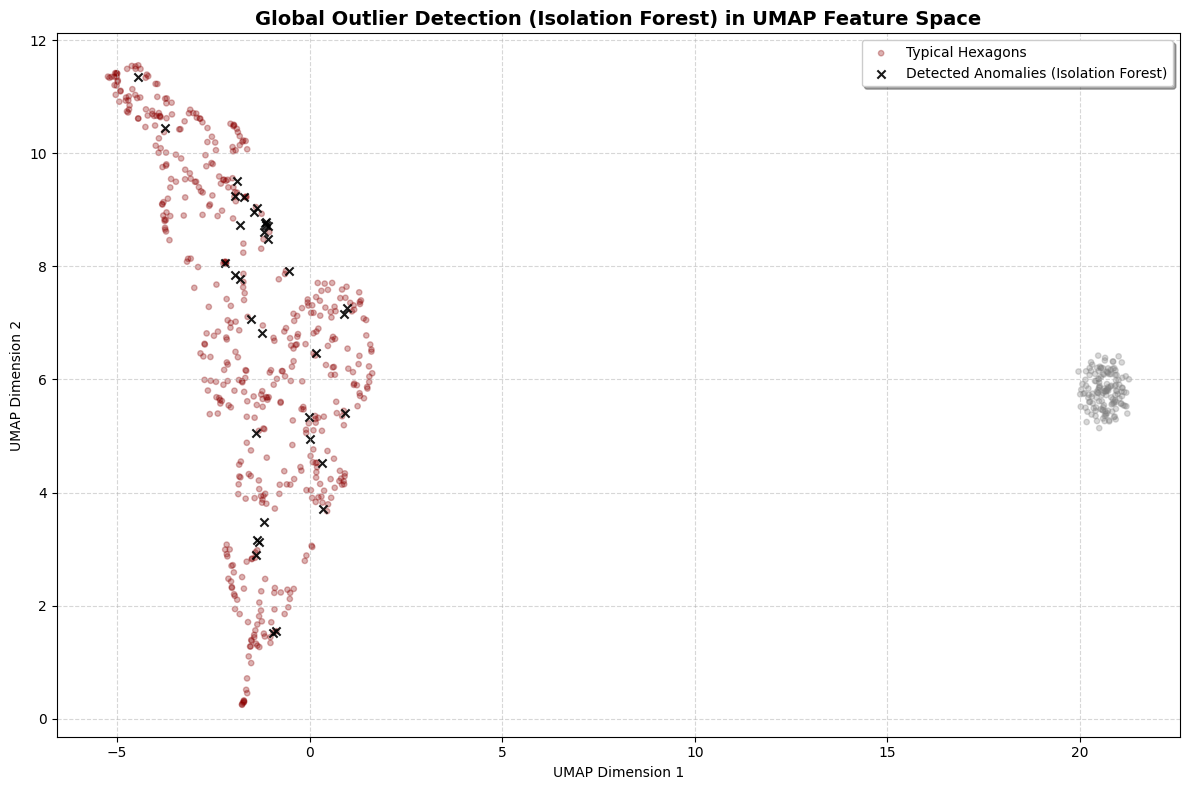

In [167]:
plt.figure(figsize=(12, 8), facecolor='white')

# 1. Plot normal observations (Background)
# We use the original dominant colors but with low alpha (transparency) 
# to keep the focus on the anomalies.
normal_points = df_final[~df_final['is_outlier']]
plt.scatter(
    normal_points["emb_x"], 
    normal_points["emb_y"], 
    c=normal_points['dominant_color'], 
    s=15, 
    alpha=0.3, 
    label='Typical Hexagons'
)

# 2. Plot global outliers (Foreground)
# We use a distinct marker ('x') and a high-contrast color (black)
# to highlight the cells that Isolation Forest identified as anomalous.
outliers = df_final[df_final['is_outlier']]
plt.scatter(
    outliers["emb_x"], 
    outliers["emb_y"], 
    c='black', 
    s=35, 
    marker='x', 
    alpha=0.9, 
    linewidths=1.5,
    label='Detected Anomalies (Isolation Forest)'
)



# 3. Chart Decoration
plt.title("Global Outlier Detection (Isolation Forest) in UMAP Feature Space", fontsize=14, fontweight='bold')
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(loc='best', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()